In [34]:
import matplotlib.pyplot as plt
import numpy as np

from model_ranking.datasets import DummySelfTrainingDataset
from pytorch3dunet.unet3d.model import get_model
from pytorch3dunet.unet3d.utils import load_checkpoint
from model_ranking.self_training import get_DummySelfTraining_loader
from model_ranking.metrics import MultiClassF1Eval

In [53]:
from typing import Dict, Any
data_cfg: Dict[str, Any] = {
    "unsupervised_train_paths": ["/scratch/talks/data/EPFL/train.h5"],
    "unsupervised_val_paths": ["/scratch/talks/data/EPFL/val.h5"],
    "patch_shape": [1, 256, 256],
    "supervised_train_paths": None,
    "supervised_val_paths": None,
    "raw_key": "raw",
    "raw_key_supervised": None,
    "label_key": "labels",
    "batch_size": 32,
    "num_workers": 1,
    "n_samples_train": 512,
    "n_samples_val": 512
}

In [54]:
loader = get_DummySelfTraining_loader(
    paths=data_cfg["unsupervised_train_paths"],
    raw_key=data_cfg["raw_key"],
    label_key=data_cfg["label_key"],
    patch_shape=data_cfg["patch_shape"],
    batch_size=data_cfg["batch_size"],
    num_workers=data_cfg["num_workers"],
    n_samples=data_cfg["n_samples_train"],
)

In [55]:
raw1_label, raw2 = next(iter(loader))
print(raw1_label.shape, raw2.shape)

torch.Size([32, 2, 1, 256, 256]) torch.Size([32, 1, 1, 256, 256])


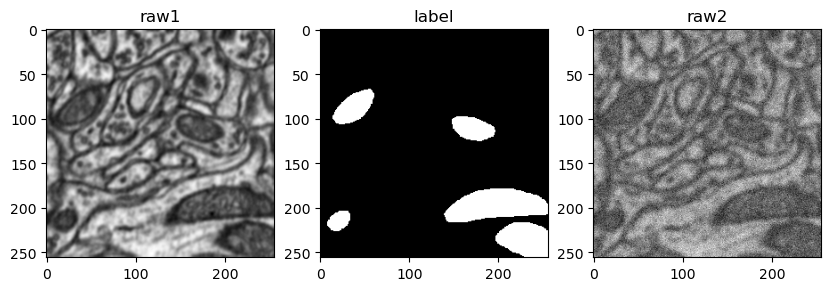

In [56]:
_, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].imshow(np.squeeze(raw1_label[0, 0].numpy()), cmap="gray")
axs[0].set_title("raw1")
axs[1].imshow(np.squeeze(raw1_label[0, 1].numpy()), cmap="gray")
axs[1].set_title("label")
axs[2].imshow(np.squeeze(raw2[0].numpy()), cmap="gray")
axs[2].set_title("raw2")
plt.show()


In [57]:
model_cfg: Dict[str, Any] = {
    "name": "UNet2d_as3d",
    "in_channels": 1,
    "out_channels": 1,
    "layer_order": "bcr",
    "f_maps": 32,
    "final_sigmoid": False,
    "feature_return": False,
    "is_segmentation": False,
    "feature_perturbation": None
}
model = get_model(model_cfg)
source_checkpoint = "/g/kreshuk/talks/segmentation_ModelSelection/experiments/Hmito/BatchNorm/Hm_model3/best_checkpoint.pytorch"
load_checkpoint(source_checkpoint, model)
model.eval()

/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_path, map_location="cpu")


UNet2d_as3d(
  (encoders): ModuleList(
    (0): Encoder(
      (basic_module): DoubleConv(
        (SingleConv1): SingleConv(
          (batchnorm): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (ReLU): ReLU(inplace=True)
        )
        (SingleConv2): SingleConv(
          (batchnorm): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (ReLU): ReLU(inplace=True)
        )
      )
    )
    (1): Encoder(
      (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (basic_module): DoubleConv(
        (SingleConv1): SingleConv(
          (batchnorm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv): Conv2d(32, 32, kernel_size=(3, 3), 

In [58]:
import torch
from tqdm import tqdm

f1_per_batch = []
with torch.no_grad():
    for raw1_label, raw2 in tqdm(loader):
        pred = model(raw1_label[:, 0:1, ...])
        f1_scores = MultiClassF1Eval()(pred, raw1_label[:, 1:2, ...])
        f1_per_batch.append(f1_scores.detach().cpu().numpy())
        
    

100%|██████████| 16/16 [02:03<00:00,  7.74s/it]


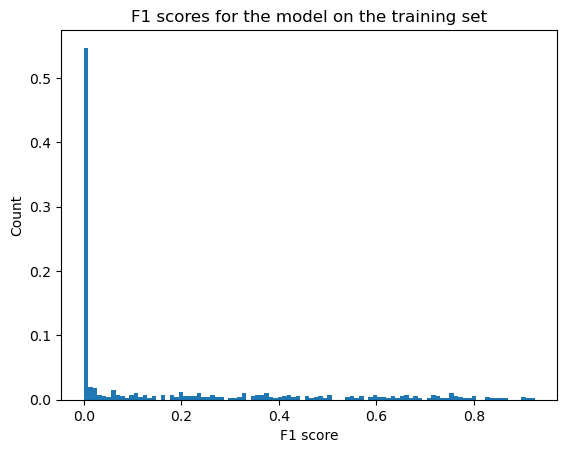

In [59]:
_ = plt.hist(np.concatenate(f1_per_batch)[:,1], bins=100, weights=np.ones(len(np.concatenate(f1_per_batch))) / len(np.concatenate(f1_per_batch)))
_ = plt.xlabel("F1 score")
_ = plt.ylabel("Count")
_ = plt.title("F1 scores for the model on the training set")
plt.show()